# Skills Analysis — Demand & Market Trends

This notebook explores the global demand for data-related skills across different categories such as programming, cloud, analyst tools, and big data technologies.

## Load Skills_df

In [1]:
# Importing required Libraries

import pandas as pd
import sys
import os

# To import custom modules from the 'src' folder
sys.path.append(os.path.abspath(".."))

# Importing custom function to process and structure skills data
from src.skills_processing import create_skills_df

# Loading the cleaned job dataset 
# (.pkl format is imported since it retains python objects like list and idctionaries unlike .csv wich converts them to string)
df = pd.read_pickle("../data/processed/cleaned_jobs.pkl")

# This function extracts, normalizes, and organizes skill information
skills_df = create_skills_df(df)

skills_df

,job_id,job_title_short,category,skill
1,J-64833455be38,Data Analyst,analyst_tools,power bi
1,J-64833455be38,Data Analyst,analyst_tools,tableau
1,J-64833455be38,Data Analyst,programming,nosql
1,J-64833455be38,Data Analyst,programming,python
1,J-64833455be38,Data Analyst,programming,r
...,...,...,...,...
785739,J-a94d273e8878,Data Engineer,programming,python
785739,J-a94d273e8878,Data Engineer,programming,shell
785739,J-a94d273e8878,Data Engineer,programming,sql
785740,J-03b27285205d,Software Engineer,cloud,aws


## Top In-Demand Skills (Global View)

This chart highlights the **overall demand distribution of the most sought-after skills** across all job postings.

This provides a **high-level view of which tools dominate the market globally**

In [2]:
# Grouping data by skill and counting the number of job postings for each skill
top_skills = (
    skills_df
    .groupby('skill')['job_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='count')
)

# Calculating percentage share of each skill among the top 15
top_skills['percent'] = (
    top_skills['count'] / top_skills['count'].sum() * 100
)

top_skills

,skill,count,percent
0,sql,384537,19.163658
1,python,380602,18.967554
2,aws,145304,7.241322
3,azure,132469,6.601681
4,r,130834,6.520200
5,tableau,127157,6.336954
6,excel,126956,6.326937
7,spark,114547,5.708526
8,power bi,98102,4.888979
9,java,85557,4.263790


### Plot Top In-Demand Skills Graph

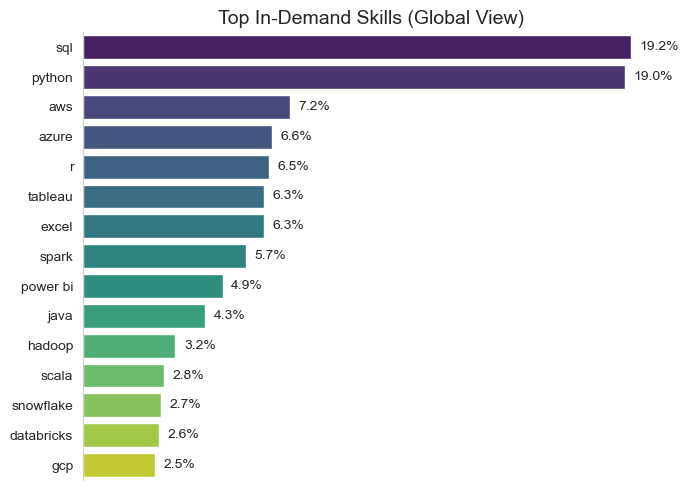

In [3]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a clean and professional visual style
sns.set_style("whitegrid")

# Sorting skills by percentage for better visual ordering
top_skills = top_skills.sort_values(by='percent', ascending=False)

# Creating figure with controlled size
plt.figure(figsize=(7, 5))

# Creating horizontal bar plot
sns.barplot(
    data=top_skills,
    x='percent',   # Percentage demand on x-axis
    y='skill',     # Skills on y-axis
    hue='skill',   # Color differentiation per skill
    palette='viridis'
)

# Adding title
plt.title("Top In-Demand Skills (Global View)", fontsize=14)

# Removing axis labels for cleaner look
plt.xlabel("")
plt.ylabel("")

# Hiding x-axis ticks (since percentages are labeled directly)
plt.xticks([])

# Adding percentage labels next to each bar
for i, v in enumerate(top_skills['percent']):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center')

# Removing unnecessary spines for minimal design
sns.despine(left=False, bottom=True)

# Adjusting layout to prevent overlap
plt.tight_layout()

# Displaying the plot
plt.show()

## Skill Demand Across Categories

This visualization combines two perspectives:

### 1. Skill Category Distribution (Donut Chart)
- Shows how demand is divided across major categories: Programming, Analyst Tools, Cloud, Libraries / Big Data, Other tools

### 2. Top Skills by Category (Scatter Plot)
- Each bubble represents a skill
- X-axis → **Demand (job count)**
- Bubble size → **Rank within category (1 = highest)**
- Colors represent **skill categories**
- Shaded sections group skills by category for better readability

In [4]:
# Counting how many times each skill category appears in the dataset
category_counts = skills_df['category'].value_counts()

# Sorting categories in descending order to highlight the most common ones
category_counts = category_counts.sort_values(ascending=False)

category_counts

category
programming      1334220
analyst_tools     630923
cloud             550722
libraries         519689
other             259659
databases         150556
os                 60114
webframeworks      39732
async              39597
sync                7935
Name: count, dtype: int64

In [5]:
# Selecting the top 5 most frequent skill categories
top_categories = category_counts.nlargest(5)

top_categories

category
programming      1334220
analyst_tools     630923
cloud             550722
libraries         519689
other             259659
Name: count, dtype: int64

In [6]:
# Grouping data by both category and skill to get granular insights
skill_counts = (
    skills_df
    .groupby(['category', 'skill'])
    .size()
    .reset_index(name='count')
)

skill_counts

,category,skill,count
0,analyst_tools,alteryx,12295
1,analyst_tools,cognos,5420
2,analyst_tools,datarobot,802
3,analyst_tools,dax,9245
4,analyst_tools,esquisse,3
...,...,...,...
249,webframeworks,rubyon rails,1
250,webframeworks,svelte,103
251,webframeworks,symfony,160
252,webframeworks,vue,2942


In [7]:
# Ranking skills within each category based on their demand (count)
skill_counts['rank'] = (
    skill_counts
    .groupby('category')['count']
    .rank(method='dense', ascending=False)
)

skill_counts

,category,skill,count,rank
0,analyst_tools,alteryx,12295,11.0
1,analyst_tools,cognos,5420,18.0
2,analyst_tools,datarobot,802,24.0
3,analyst_tools,dax,9245,14.0
4,analyst_tools,esquisse,3,27.0
...,...,...,...,...
249,webframeworks,rubyon rails,1,29.0
250,webframeworks,svelte,103,21.0
251,webframeworks,symfony,160,19.0
252,webframeworks,vue,2942,6.0


In [8]:
# Sorting skills by category and count
# Then selecting the top 3 skills within each category
top_skills = (
    skill_counts
    .sort_values(['category', 'count'], ascending=[True, True])
    .groupby('category')
    .tail(3)
)

top_skills

,category,skill,count,rank
12,analyst_tools,power bi,98102,3.0
5,analyst_tools,excel,126956,2.0
25,analyst_tools,tableau,127157,1.0
36,async,notion,1802,3.0
31,async,confluence,10745,2.0
33,async,jira,23486,1.0
59,cloud,snowflake,54990,3.0
45,cloud,azure,132469,2.0
44,cloud,aws,145304,1.0
73,databases,postgresql,20687,3.0


In [9]:
# Defining key categories relevant to data roles
selected_categories = ['analyst_tools', 'programming', 'cloud', 'libraries', 'other']

# Filtering top skills to include only selected categories
top_skills_filtered = top_skills[
    top_skills['category'].isin(selected_categories)
]

top_skills_filtered

,category,skill,count,rank
12,analyst_tools,power bi,98102,3.0
5,analyst_tools,excel,126956,2.0
25,analyst_tools,tableau,127157,1.0
59,cloud,snowflake,54990,3.0
45,cloud,azure,132469,2.0
44,cloud,aws,145304,1.0
95,libraries,kafka,49912,3.0
90,libraries,hadoop,64814,2.0
115,libraries,spark,114547,1.0
147,other,kubernetes,37331,3.0


### Plot Skills Demand Analysis Across Categories Graph

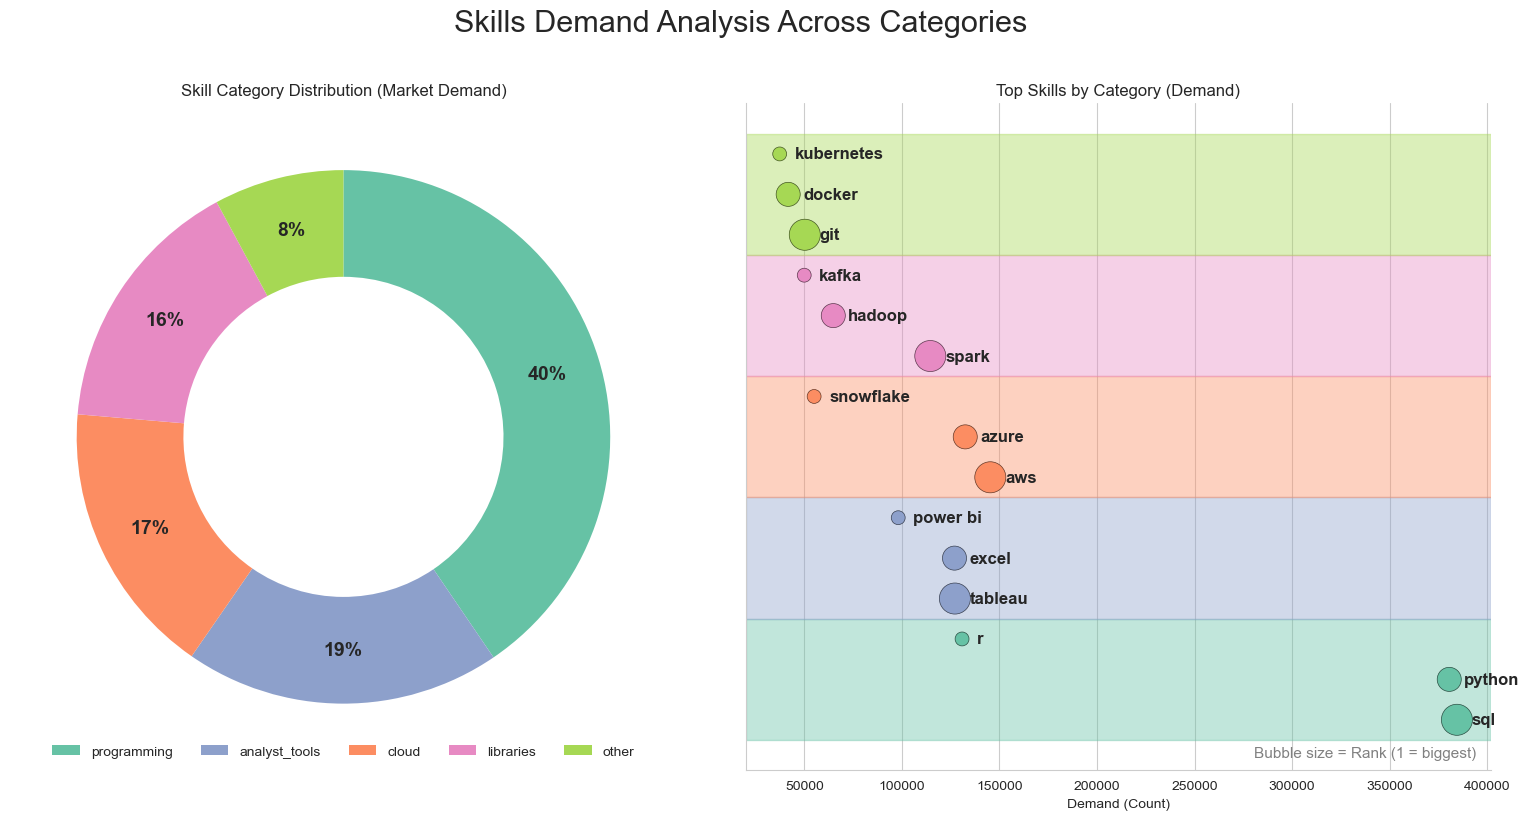

In [10]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Setting visual style
sns.set_style("whitegrid")

# Creating a figure with two subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Defining custom colors for each category
category_colors = {
    'programming': '#66c2a5',
    'cloud': '#fc8d62',
    'analyst_tools': '#8da0cb',
    'libraries': '#e78ac3',
    'other': '#a6d854'
}

# Creating a copy of filtered data for plotting
df_category_plot = top_skills_filtered.copy()

# Creating y-axis positions for custom layout
df_category_plot['y_pos'] = range(len(df_category_plot))

# Defining category order for structured grouping
category_order = [
    'programming',
    'analyst_tools',
    'cloud',
    'libraries',
    'other'
]

# Converting category column into ordered categorical type
df_category_plot['category'] = pd.Categorical(
    df_category_plot['category'],
    categories=category_order,
    ordered=True
)

# Sorting data for proper grouping and ranking display
df_category_plot = df_category_plot.sort_values(['category', 'rank'])

# Recomputing y positions after sorting
df_category_plot['y_pos'] = range(len(df_category_plot))


# ------------------ LEFT PLOT: DONUT CHART ------------------

axes[0].pie(
    top_categories,                              # Category counts
    labels=None,
    autopct='%1.0f%%',                           # Percentage labels
    startangle=90,
    counterclock=False,
    pctdistance=0.8,
    colors=[category_colors[c] for c in top_categories.index],
    wedgeprops={'width': 0.4, 'edgecolor': 'none'},  # Donut style
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

axes[0].set_title("Skill Category Distribution (Market Demand)")

# Adding legend for categories
axes[0].legend(
    top_categories.index,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.0),
    ncol=5,
    frameon=False,
)


# ------------------ RIGHT PLOT: BUBBLE CHART ------------------

sns.scatterplot(
    data=df_category_plot,
    x='count',                # Demand (number of job mentions)
    y='y_pos',                # Custom y positions
    hue='category',           # Color by category
    palette=category_colors,
    size='rank',              # Bubble size represents rank
    sizes=(500, 100),         # Larger bubble = higher rank
    edgecolor='black',
    linewidth=0.5,
    ax=axes[1]
)

# Offset for label placement
offset = df_category_plot['count'].max() * 0.02

# Adding skill labels next to each bubble
for _, row in df_category_plot.iterrows():
    axes[1].text(
        row['count'] + offset,
        row['y_pos'],
        row['skill'],
        va='center',
        fontsize=12,
        fontweight='bold'
    )

# Adding shaded background for each category group
import matplotlib.colors as mcolors

for category in category_order:
    group = df_category_plot[df_category_plot['category'] == category]
    ymin = group['y_pos'].min() - 0.5
    ymax = group['y_pos'].max() + 0.5

    base_color = category_colors[category]
    light_color = mcolors.to_rgba(base_color, alpha=0.4)

    axes[1].axhspan(ymin, ymax, color=light_color)

# Cleaning up axes
axes[1].set_yticks(df_category_plot['y_pos'])
axes[1].set_yticklabels([])   # Hide default labels (custom labels used)

axes[1].set_title("Top Skills by Category (Demand)")
axes[1].set_xlabel("Demand (Count)")
axes[1].set_ylabel("")

# Removing y-axis ticks for cleaner look
axes[1].set_yticks([])

# Adding annotation for bubble size meaning
axes[1].text(
    0.98, 0.02,
    "Bubble size = Rank (1 = biggest)",
    transform=axes[1].transAxes,
    ha='right',
    fontsize=11,
    color='gray'
)

# Removing legend (redundant due to color grouping)
axes[1].legend_.remove()

# Overall title
fig.suptitle("Skills Demand Analysis Across Categories", fontsize=22, y=1.02)

# Removing unnecessary spines
sns.despine()

# Adjust layout
plt.tight_layout()

# Display plot
plt.show()

In [11]:
df_category_plot

,category,skill,count,rank,y_pos
204,programming,sql,384537,1.0,0
195,programming,python,380602,2.0,1
196,programming,r,130834,3.0,2
25,analyst_tools,tableau,127157,1.0,3
5,analyst_tools,excel,126956,2.0,4
12,analyst_tools,power bi,98102,3.0,5
44,cloud,aws,145304,1.0,6
45,cloud,azure,132469,2.0,7
59,cloud,snowflake,54990,3.0,8
115,libraries,spark,114547,1.0,9


 Key Insights

- Programming dominates the market, accounting for the largest share of demand, driven primarily by SQL and Python.
- SQL and Python are foundational skills, significantly outperforming all others in global demand.
- Cloud platforms (AWS, Azure) form the second major demand cluster, highlighting the importance of cloud expertise.
- Analyst tools like Excel, Tableau, and Power BI remain highly relevant, indicating continued demand for business intelligence and reporting skills.
- Big data technologies (Spark, Hadoop, Kafka) show moderate but specialized demand, often tied to data engineering roles.
- Supporting tools (Git, Docker, Kubernetes), while smaller in share, are essential for production and deployment workflows.